In [93]:
import os

from methods_script.toroidal_filament.parameters import calibration_coeff, R as a_p, coil_angle_dict

import pandas as pd
import numpy as np
from scipy.constants import mu_0
from matplotlib import pyplot as plt

In [102]:
shot_num = 1641
t_min, t_max = 340, 440

# region --- Read Experimental data ---
data_dir = os.path.join(
    'data', str(shot_num)
)

probe_names = [f'GBP{i+1}T' for i in range(12)]
signal_names =  probe_names + ['IP1'] + ['IT1'] + ['IOH1'] + ['IV1']

signal_df = pd.DataFrame(columns=['time'] + signal_names)

for name in signal_names:
    path = os.path.join(data_dir, f'{name}.txt')

    raw = np.loadtxt(path, skiprows=8)
    time, data = raw[:,0], raw[:,1]

    signal_df[name] = data

signal_df['time'] = time

# keep only rows within [t_min, t_max]
signal_df = signal_df[
    (signal_df['time'] >= t_min) & (signal_df['time'] <= t_max)
].reset_index(drop=True)

# endregion

for i in range(12):
    coil_name = f'GBP{i+1}T'

    toroidal_effect = calibration_coeff[f'k{i+1}t'] * signal_df['IT1']
    ohmic_effect = calibration_coeff[f'k{i+1}oh'] * signal_df['IOH1']
    vertical_effect = calibration_coeff[f'k{i+1}v'] * signal_df['IV1']

    signal_df[coil_name] -= (toroidal_effect + ohmic_effect + vertical_effect)

signal_df

,time,GBP1T,GBP2T,GBP3T,GBP4T,GBP5T,GBP6T,GBP7T,GBP8T,GBP9T,GBP10T,GBP11T,GBP12T,IP1,IT1,IOH1,IV1
0,340.006400,-0.028008,-0.032184,-0.036354,-0.020710,-0.010230,-0.077681,-0.015417,-0.005806,-0.004898,-0.023598,-0.046767,-0.006014,30089.826172,-4427.206543,8507.134766,1121.014893
1,340.026399,-0.028074,-0.032248,-0.036390,-0.020770,-0.010390,-0.078016,-0.015946,-0.006196,-0.005039,-0.023745,-0.046979,-0.006092,30161.937500,-4428.230957,8496.796875,1121.335327
2,340.046398,-0.027961,-0.032264,-0.036443,-0.020756,-0.010336,-0.077963,-0.015866,-0.006173,-0.004990,-0.023702,-0.046981,-0.006073,30166.744141,-4427.718750,8493.533203,1123.578491
3,340.066397,-0.028006,-0.032284,-0.036487,-0.020781,-0.010349,-0.078004,-0.015872,-0.006117,-0.005077,-0.023698,-0.046979,-0.006072,30089.826172,-4428.230957,8488.091797,1124.379761
4,340.086397,-0.027973,-0.032302,-0.036514,-0.020779,-0.010366,-0.078021,-0.015806,-0.006065,-0.004993,-0.023707,-0.047179,-0.006092,30123.478516,-4424.645020,8489.179688,1127.263916
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,439.902404,-0.015643,-0.015174,-0.015938,-0.010910,-0.009757,-0.068860,-0.012166,-0.005029,-0.004491,-0.016066,0.002958,-0.000600,17720.703125,-4421.058594,-2917.207031,371.920868
4996,439.922403,-0.016092,-0.015137,-0.015924,-0.010891,-0.009750,-0.068808,-0.012469,-0.004972,-0.004473,-0.016028,0.002975,-0.000576,17663.015625,-4421.570801,-2915.030762,370.959473
4997,439.942402,-0.015921,-0.015153,-0.015917,-0.010885,-0.009740,-0.068795,-0.012255,-0.004929,-0.004455,-0.016024,0.002983,-0.000588,17663.015625,-4420.802734,-2917.207031,371.119690
4998,439.962402,-0.016161,-0.015138,-0.015909,-0.010864,-0.009753,-0.068792,-0.012461,-0.005008,-0.004488,-0.015958,0.003160,-0.000579,17590.904297,-4422.852051,-2918.839355,369.196899


In [103]:
# region --- Ip optimization ---

# Response matrix
coil_theta = [coil_angle_dict[i+1] for i in range(12)]
response_matrix = mu_0/(2*np.pi*a_p) * np.array([
    [1, np.cos(theta_i)/a_p, np.sin(theta_i)/a_p] for theta_i in coil_theta
])

# Weight matrix
weight_matrix = np.diag([5,5,5,3,2,0,2,1,1,2,0,1])
# weight_matrix = np.diag([5,4,4,4,3,0,0,0,0,3,0,0])

result = []

for row_num in range(len(signal_df)):
    # Magnetic signal vector
    signal_vector = signal_df[probe_names].iloc[row_num]

    # solution vector x = [Ip, dU*Ip, dV*Ip]
    x = np.linalg.inv(
        response_matrix.T @ weight_matrix @ response_matrix
        ) @ response_matrix.T @ weight_matrix @ signal_vector

    result.append([-x[0], x[1]/x[0], x[2]/x[0]])

result = pd.DataFrame(data=result, columns=['IP', 'dU', 'dV'])

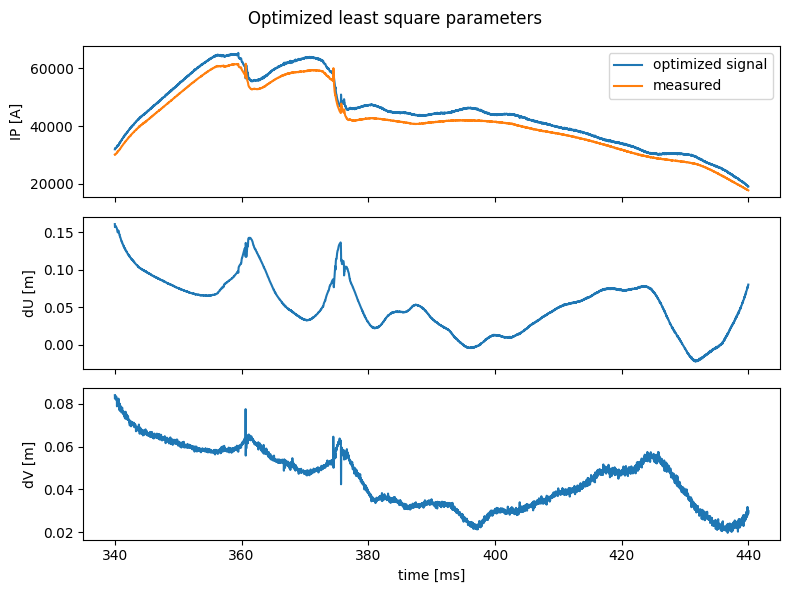

In [104]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(8,6), sharex=True)

axs[0].plot(signal_df['time'], result['IP'], label = 'optimized signal')
axs[0].plot(signal_df['time'], signal_df['IP1'], label = 'measured')
axs[0].set_ylabel('IP [A]')
axs[0].legend(loc='upper right')

axs[1].plot(signal_df['time'], result['dU'])
axs[1].set_ylabel('dU [m]')

axs[2].plot(signal_df['time'], result['dV'])
axs[2].set_ylabel('dV [m]')
axs[2].set_xlabel('time [ms]')

fig.suptitle('Optimized least square parameters')
fig.tight_layout()

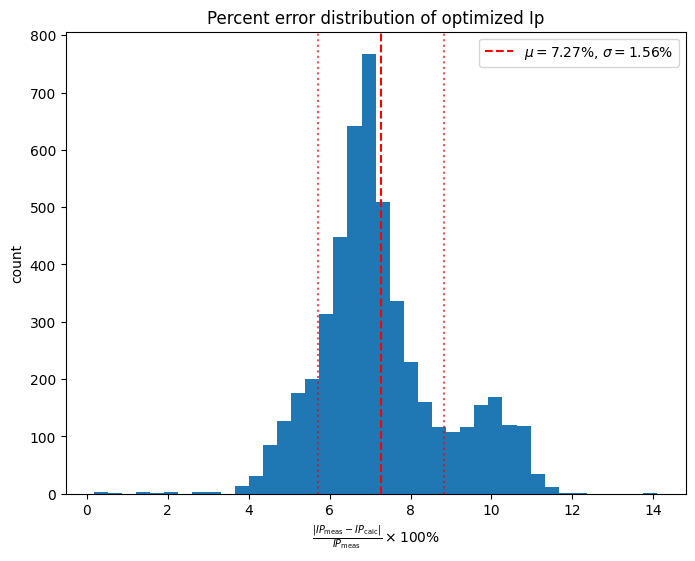

In [105]:
ip_percent_diff = np.abs(signal_df['IP1'] - result['IP'])/(signal_df['IP1']) * 100

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8,6))

ax.hist(ip_percent_diff, bins=40)
ax.set_xlabel(r'$\frac{|IP_{\mathrm{meas}} - IP_{\mathrm{calc}}|}{IP_{\mathrm{meas}}} \times 100\%$')
ax.set_ylabel('count')
ax.set_title('Percent error distribution of optimized Ip')


mean = np.mean(ip_percent_diff)
std = np.std(ip_percent_diff)   # population std
# std = np.std(ip_percent_diff, ddof=1)  # sample std

ax.axvline(mean, color='red', ls='--',
           label=rf'$\mu = {mean:.2f}\%$, $\sigma = {std:.2f}\%$')

ax.axvline(mean - std, color='red', ls=':', alpha=0.7)
ax.axvline(mean + std, color='red', ls=':', alpha=0.7)

ax.legend()